Student Number - 740090003

In [124]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import scipy.stats as stats

pd.read_csv("investigating_hrv_dataset/y01.csv")

,time,type
0,208,N
1,944,N
2,1688,N
3,2440,N
4,3196,N
...,...,...
8705,7220600,N
8706,7221864,N
8707,7222916,N
8708,7223760,N


In [126]:
#Task 1 calculating the HRV metrics for file y01.csv
file_in = ("investigating_hrv_dataset/y01.csv")   #location of file y01.csv
def calculate_HRV_metrics(file_in):
    
    df = pd.read_csv(file_in)
    df['time_next'] = df['time'].shift(-1)
    df['type_next'] = df['type'].shift(-1)
    df['rr'] = df['time_next'] - df['time']
    df['rr_type'] =  df['type'] + df['type_next']
    df['rr_next'] = df['rr'].shift(-1)
    df['rr_next_type'] = df['rr_type'].shift(-1)
    df['diff'] = df['rr_next'] - df['rr']
    df['diff_squared'] = df['diff']**2
    df_NN_intervals= df.query("rr_type == 'NN'")    
    n = len(df_NN_intervals)
    
    df_NN_ToNN_intervals = df_NN_intervals.query(" rr_next_type== 'NN'")
    if df_NN_intervals['rr'].count() < 500:
        mean_nn = None
        sd_nn = None
        mean_bpm = None
    else:
        mean_nn = df_NN_intervals['rr'].mean()
        sd_nn = df_NN_intervals['rr'].std()
        mean_bpm = 60*1000/mean_nn
     
    if df_NN_ToNN_intervals['diff'].count() < 500:
        RMSSD = None
        pNN20 = None
        pNN50 = None
    else:
        RMSSD = df_NN_ToNN_intervals['diff_squared'].mean() ** 0.5
        total = df_NN_ToNN_intervals['diff'].count()
        k = len( df_NN_ToNN_intervals.query("diff>20 or diff<-20") )
        pNN20 = (k/total)*100
        l = len( df_NN_ToNN_intervals.query("diff>50 or diff<-50") )
        pNN50 = (l/total)*100
    results = {
        'file': os.path.basename(file_in), # returns the file name from the path directory
        'n': n,
        'mean_nn': round(mean_nn),
        'mean_bpm':round(mean_bpm,1),
        'sd_nn': round(sd_nn,1),
        'RMSSD': round(RMSSD,1),
        'pNN20': round(pNN20,1),
        'pNN50': round(pNN50,1),        
    }
    return results

In [128]:
calculate_HRV_metrics(file_in)

{'file': 'y01.csv',
 'n': 8705,
 'mean_nn': 830,
 'mean_bpm': 72.3,
 'sd_nn': 93.0,
 'RMSSD': 91.9,
 'pNN20': 75.3,
 'pNN50': 47.0}

In [132]:
#Task 2
file_list_in = ["investigating_hrv_dataset/y01.csv", "investigating_hrv_dataset/y02.csv", "investigating_hrv_dataset/y03.csv"]
file_out = "outputs.csv"
def process_HRV_files(file_list_in, file_out):
    task_data = []
   #catch the error and print a statement about the missing file
    for file in file_list_in:
        try:
            task_data.append(calculate_HRV_metrics(file))
        except FileNotFoundError as error:            
            print("{}.The file {} cannot be found !!!".format(error,file))
            
    df = pd.DataFrame(task_data)            #saving the results into a dataframe
    df.to_csv(file_out, index = False)      #store the result in a csv format
    
    return file_out

In [134]:
pd.read_csv(process_HRV_files(file_list_in, file_out))

,file,n,mean_nn,mean_bpm,sd_nn,RMSSD,pNN20,pNN50
0,y01.csv,8705,830,72.3,93.0,91.9,75.3,47.0
1,y02.csv,6916,1031,58.2,98.5,71.3,71.7,44.8
2,y03.csv,7641,952,63.0,65.8,34.5,49.2,13.7


In [136]:
#Task 3
#apply the results on all the csv files in the data provided and store in fantasia.csv file
y= os.listdir("investigating_hrv_dataset")[:-1]
file_list_in=[os.path.join("investigating_hrv_dataset", entry) for entry in y ]
file_out = "fantasia.csv" 
def process_HRV_files(file_list_in, file_out):
    task_data = []
   
    for file in file_list_in:
        try:
            task_data.append(calculate_HRV_metrics(file))
        except FileNotFoundError as error:            
            print("{}.The file {} cannot be found !!!".format(error,file))
            
    df = pd.DataFrame(task_data)            #saving the results into a dataframe
    df.to_csv(file_out, index = False)      #store the result in a csv format
    
    return file_out
 

In [138]:
pd.read_csv(process_HRV_files(file_list_in,file_out))

,file,n,mean_nn,mean_bpm,sd_nn,RMSSD,pNN20,pNN50
0,o01.csv,7168,1011,59.3,48.0,15.5,13.0,0.6
1,o02.csv,6796,1062,56.5,33.7,15.0,12.6,0.4
2,o03.csv,7203,1004,59.8,47.9,23.7,26.9,3.1
3,o04.csv,6213,1163,51.6,116.3,118.1,40.3,12.5
4,o05.csv,5725,1088,55.2,43.2,11.3,6.0,0.1
5,o06.csv,6216,1168,51.4,23.9,19.9,24.6,0.7
6,o07.csv,7035,1014,59.2,50.7,27.0,33.2,4.6
7,o08.csv,8462,850,70.6,43.8,24.2,32.6,3.4
8,o09.csv,4731,1483,40.4,94.4,66.5,67.9,35.1
9,o10.csv,8238,880,68.2,57.3,20.9,27.7,2.0


In [72]:
pd.read_csv("fantasia.csv")

,file,n,mean_nn,mean_bpm,sd_nn,RMSSD,pNN20,pNN50
0,o01.csv,7168,1011,59.3,48.0,15.5,13.0,0.6
1,o02.csv,6796,1062,56.5,33.7,15.0,12.6,0.4
2,o03.csv,7203,1004,59.8,47.9,23.7,26.9,3.1
3,o04.csv,6213,1163,51.6,116.3,118.1,40.3,12.5
4,o05.csv,5725,1088,55.2,43.2,11.3,6.0,0.1
5,o06.csv,6216,1168,51.4,23.9,19.9,24.6,0.7
6,o07.csv,7035,1014,59.2,50.7,27.0,33.2,4.6
7,o08.csv,8462,850,70.6,43.8,24.2,32.6,3.4
8,o09.csv,4731,1483,40.4,94.4,66.5,67.9,35.1
9,o10.csv,8238,880,68.2,57.3,20.9,27.7,2.0


In [76]:
# loading fantasia.csv into hrv_df
hrv_df = pd.read_csv("fantasia.csv")

In [78]:
hrv_df


,file,n,mean_nn,mean_bpm,sd_nn,RMSSD,pNN20,pNN50
0,o01.csv,7168,1011,59.3,48.0,15.5,13.0,0.6
1,o02.csv,6796,1062,56.5,33.7,15.0,12.6,0.4
2,o03.csv,7203,1004,59.8,47.9,23.7,26.9,3.1
3,o04.csv,6213,1163,51.6,116.3,118.1,40.3,12.5
4,o05.csv,5725,1088,55.2,43.2,11.3,6.0,0.1
5,o06.csv,6216,1168,51.4,23.9,19.9,24.6,0.7
6,o07.csv,7035,1014,59.2,50.7,27.0,33.2,4.6
7,o08.csv,8462,850,70.6,43.8,24.2,32.6,3.4
8,o09.csv,4731,1483,40.4,94.4,66.5,67.9,35.1
9,o10.csv,8238,880,68.2,57.3,20.9,27.7,2.0


In [80]:
# add information about sex and age to the hrv_dataframe
df_individual = pd.read_csv("fantasia_individuals.csv") # load the data fantasia_individuals.csv in to a dataframe
df_individual = df_individual.drop('group', axis = 1) # remove the group category from the new dataframe
hrv_df= pd.merge(hrv_df, df_individual, on="file") # add the columns of the new dataframe to hrv_df
hrv_df

,file,n,mean_nn,mean_bpm,sd_nn,RMSSD,pNN20,pNN50,age,sex
0,o01.csv,7168,1011,59.3,48.0,15.5,13.0,0.6,77,F
1,o02.csv,6796,1062,56.5,33.7,15.0,12.6,0.4,73,F
2,o03.csv,7203,1004,59.8,47.9,23.7,26.9,3.1,73,M
3,o04.csv,6213,1163,51.6,116.3,118.1,40.3,12.5,81,M
4,o05.csv,5725,1088,55.2,43.2,11.3,6.0,0.1,76,M
5,o06.csv,6216,1168,51.4,23.9,19.9,24.6,0.7,74,F
6,o07.csv,7035,1014,59.2,50.7,27.0,33.2,4.6,68,M
7,o08.csv,8462,850,70.6,43.8,24.2,32.6,3.4,73,F
8,o09.csv,4731,1483,40.4,94.4,66.5,67.9,35.1,71,M
9,o10.csv,8238,880,68.2,57.3,20.9,27.7,2.0,71,F


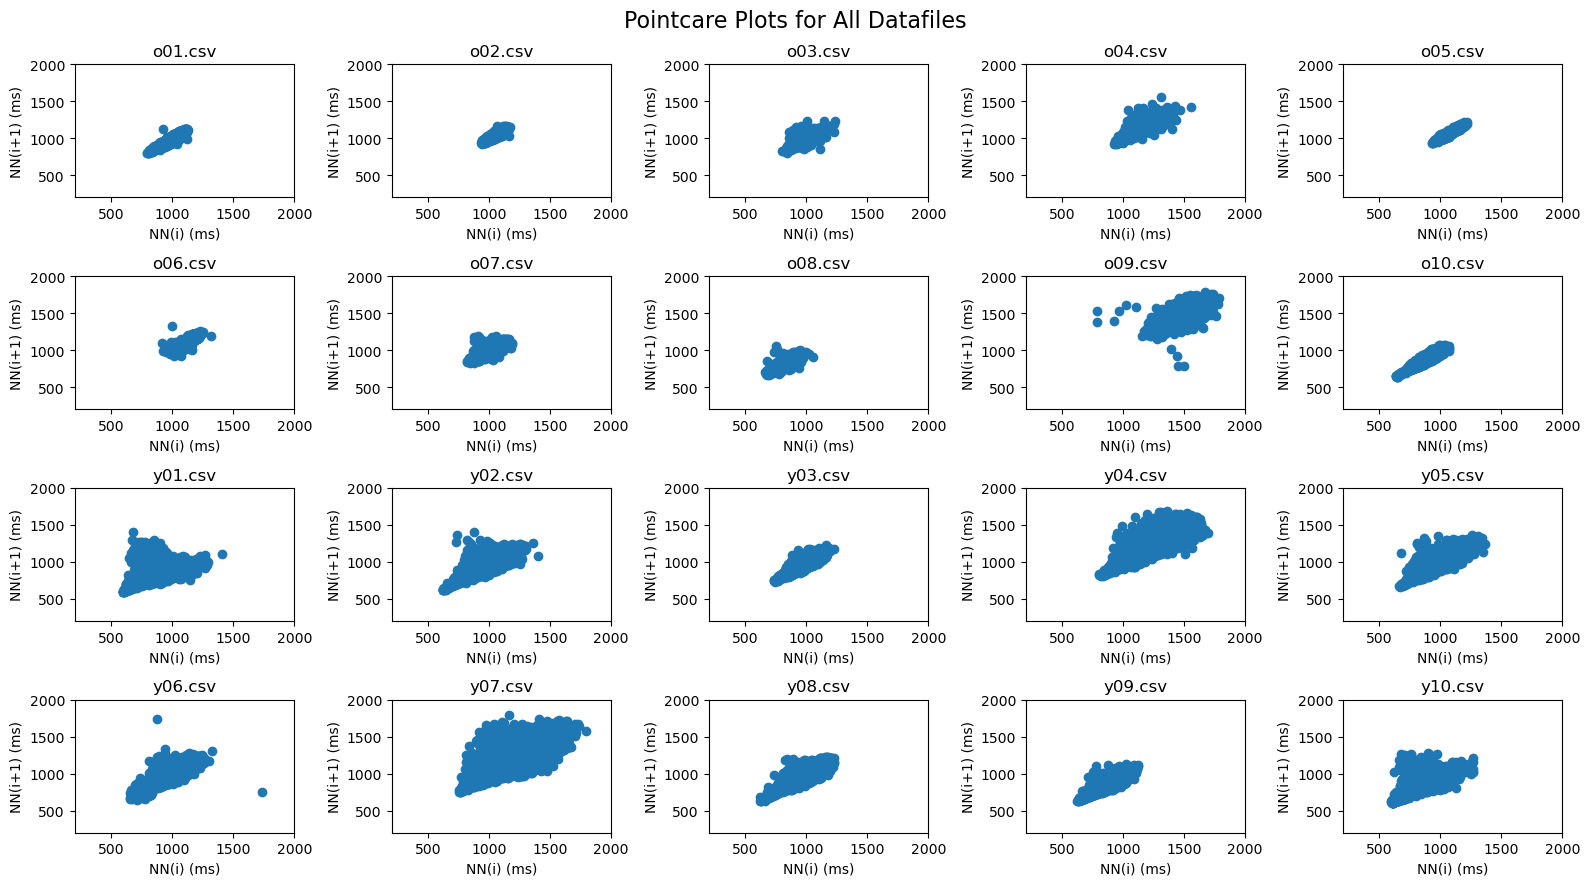

In [140]:
#Task 4

# create a figure with 4 rows & 5 columns of axes
fig,ax_array = plt.subplots(4,5, figsize=(16,9))

# to help us loop over the axes we can flatten them
# so that they are a list of the 20 axes objects 
# making up the 4 x 5 arrangement
ax_list = ax_array.flatten()

for i in range(len(file_list_in)):
    datafile = file_list_in[i]
    ax = ax_list[i]
    df = pd.read_csv(datafile)
    df['time_next'] = df['time'].shift(-1)
    df['type_next'] = df['type'].shift(-1)
    df['rr'] = df['time_next'] - df['time']
    df['rr_type'] =  df['type'] + df['type_next']
    df['rr_next'] = df['rr'].shift(-1)
    df['rr_next_type'] = df['rr_type'].shift(-1)
    df['diff'] = df['rr_next'] - df['rr']
    df['diff_squared'] = df['diff']**2
    df_NN_intervals= df.query("rr_type == 'NN'")
    n = len(df_NN_intervals)
    df_NN_ToNN_intervals = df_NN_intervals.query(" rr_next_type== 'NN'")
    filename = os.path.basename(datafile)
    # plot data
    x = df_NN_ToNN_intervals['rr']
    y=df_NN_ToNN_intervals['rr_next']
    ax.scatter(x,y)

    # customise plot
    ax.set_xlabel("NN(i) (ms)")
    ax.set_ylabel("NN(i+1) (ms)")
    ax.set_xlim(200, 2000)
    ax.set_ylim(200, 2000)
    ax.set_title(filename)

fig.subplots_adjust(top=0.88)    #to create space for the title
fig.suptitle("Pointcare Plots for All Datafiles", fontsize=16)
# use tight layout to help prevent overlaps
fig.tight_layout()


In [84]:
#Task 5
# add information about group to the hrv_dataframe
df_individual_test = pd.read_csv("fantasia_individuals.csv")
df_individual_test = df_individual_test.drop(['age','sex'], axis = 1)
hrv_df= pd.merge(hrv_df, df_individual_test, on="file")
hrv_df

,file,n,mean_nn,mean_bpm,sd_nn,RMSSD,pNN20,pNN50,age,sex,group
0,o01.csv,7168,1011,59.3,48.0,15.5,13.0,0.6,77,F,old
1,o02.csv,6796,1062,56.5,33.7,15.0,12.6,0.4,73,F,old
2,o03.csv,7203,1004,59.8,47.9,23.7,26.9,3.1,73,M,old
3,o04.csv,6213,1163,51.6,116.3,118.1,40.3,12.5,81,M,old
4,o05.csv,5725,1088,55.2,43.2,11.3,6.0,0.1,76,M,old
5,o06.csv,6216,1168,51.4,23.9,19.9,24.6,0.7,74,F,old
6,o07.csv,7035,1014,59.2,50.7,27.0,33.2,4.6,68,M,old
7,o08.csv,8462,850,70.6,43.8,24.2,32.6,3.4,73,F,old
8,o09.csv,4731,1483,40.4,94.4,66.5,67.9,35.1,71,M,old
9,o10.csv,8238,880,68.2,57.3,20.9,27.7,2.0,71,F,old


In [86]:
# create two dataframes containing information for age group
hrv_df_young = hrv_df[hrv_df['group'] == 'young']
hrv_df_old = hrv_df[hrv_df['group'] == 'old']
hrv_df_young.head()


,file,n,mean_nn,mean_bpm,sd_nn,RMSSD,pNN20,pNN50,age,sex,group
10,y01.csv,8705,830,72.3,93.0,91.9,75.3,47.0,23,F,young
11,y02.csv,6916,1031,58.2,98.5,71.3,71.7,44.8,28,F,young
12,y03.csv,7641,952,63.0,65.8,34.5,49.2,13.7,34,M,young
13,y04.csv,5485,1314,45.7,122.6,105.8,85.2,66.9,31,M,young
14,y05.csv,6943,1048,57.3,101.7,53.2,65.4,27.8,23,M,young


In [88]:
#calculate a t-test for comparing two independent samples, young and old, for heart rate (mean_bpm)

result = stats.ttest_ind(hrv_df_young['mean_bpm'], hrv_df_old['mean_bpm'])
result.statistic, result.pvalue

(0.8018337897636524, 0.43310787928410777)

The result of the t-test above showed that the t-statisctic is 0.80 and the p=value is 0.43. The p-value represents the probability that we see the t-statistic under the null hypothesis.  The null hypothesis is that there is no difference in heart rate between old and young people. Given that the significant level is 0.05, there is a high likelihood that we are going to see the t-statistic under the null hypothesis. Therefore, there is no statistical evidence against the null hypothesis. We fail to reject the null hypothesis. 

In [90]:
#calculate the mean and standard error of the two samples
young_mean_meanbpm = hrv_df_young['mean_bpm'].mean()
print(young_mean_meanbpm)
n = len(hrv_df_young['mean_bpm'])
young_stderr_meanbpm = hrv_df_young['mean_bpm'].std()/n**0.5
print(young_stderr_meanbpm)

old_mean_meanbpm = hrv_df_old['mean_bpm'].mean()
print(old_mean_meanbpm)
n = len(hrv_df_old['mean_bpm'])
old_stderr_meanbpm = hrv_df_old['mean_bpm'].std()/n**0.5
print(old_stderr_meanbpm)

60.31999999999999
2.7442384088202765
57.220000000000006
2.723266013039816


Text(0.5, 1.0, 'Dot plot of heart rate of young people vs heart rate of old people')

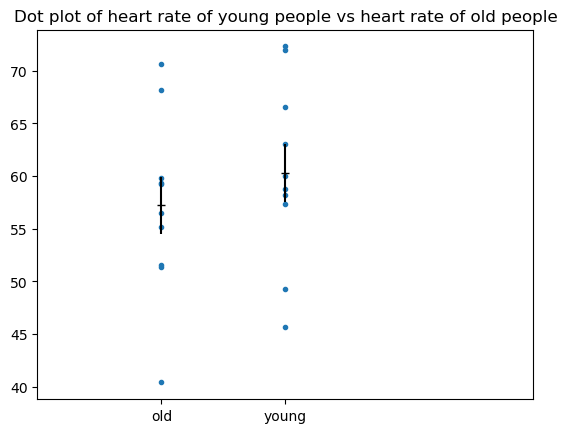

In [92]:
# create a dot plot with error bars of heart rate in old and young people
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(hrv_df['group'],hrv_df['mean_bpm'],'.')

ax.set_xlim(-1,3)

# draw the mean with error bars 
ax.errorbar(x=['young'], y=[young_mean_meanbpm], yerr=[young_stderr_meanbpm],  marker='_',  color='black')
ax.errorbar(x=['old'], y=[old_mean_meanbpm], yerr=[old_stderr_meanbpm],  marker='_',  color='black')

ax.set_title("Dot plot of heart rate of young people vs heart rate of old people")

Text(0.5, 1.0, 'Box plot of heart rate of young people vs heart rate of old people')

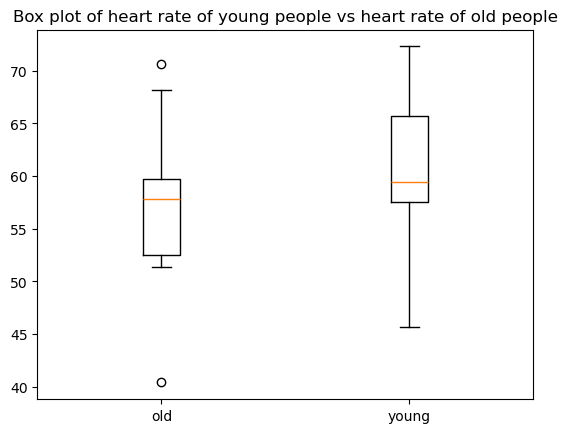

In [94]:
plt.boxplot([ hrv_df_old['mean_bpm'], 
             hrv_df_young['mean_bpm']],
             labels = ['old','young']
           );
plt.title('Box plot of heart rate of young people vs heart rate of old people')

In [96]:
#calculate a t-test for comparing two independent samples, young and old, for heart rate variability (RMSSD)

result = stats.ttest_ind(hrv_df_young['RMSSD'], hrv_df_old['RMSSD'])
result.statistic, result.pvalue

(2.498764078850751, 0.02236539950488641)

The result of the t-test above showed that the t-statistic is 2.49 and the p=value is 0.02. The p-value represents the probability that we see the t-statistic under the null hypothesis. The null hypothesis is that there is no difference in heart rate variability between old and young people. Given that the significant level is 0.05, there is a small likelihood that we are going to see the t-statistic under the null hypothesis. Therefore, there is statistical evidence against the null hypothesis. We reject the null hypothesis.

In [98]:
#calculate the mean and standard error of the two samples
young_mean_RMSSD = hrv_df_young['RMSSD'].mean()
print(young_mean_RMSSD)
n = len(hrv_df_young['RMSSD'])
young_stderr_RMSSD = hrv_df_young['RMSSD'].std()/n**0.5
print(young_stderr_RMSSD)

old_mean_RMSSD = hrv_df_old['RMSSD'].mean()
print(old_mean_RMSSD)
n = len(hrv_df_old['RMSSD'])
old_stderr_RMSSD = hrv_df_old['RMSSD'].std()/n**0.5
print(old_stderr_meanbpm)

70.41999999999999
9.961445678213579
34.209999999999994
2.723266013039816


Text(0.5, 1.0, 'Dot plot of Heart rate variability of young people vs \nheart rate variability of old people')

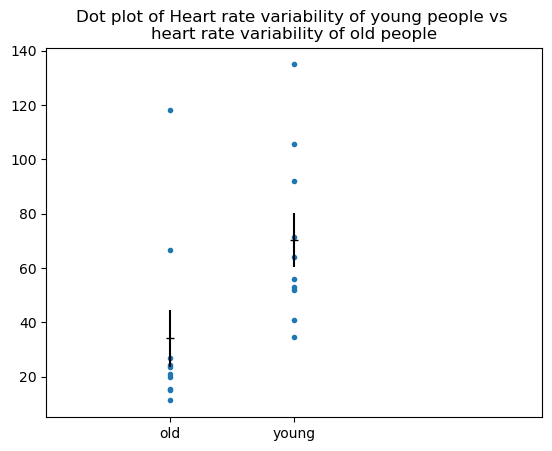

In [100]:
# create a dot plot with error bars of heart variability in old and young people
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(hrv_df['group'],hrv_df['RMSSD'],'.')

ax.set_xlim(-1,3)

# draw the mean with error bars 
ax.errorbar(x=['young'], y=[young_mean_RMSSD], yerr=[young_stderr_RMSSD],  marker='_',  color='black')
ax.errorbar(x=['old'], y=[old_mean_RMSSD], yerr=[old_stderr_RMSSD],  marker='_',  color='black')

ax.set_title("Dot plot of Heart rate variability of young people vs \nheart rate variability of old people")

Text(0.5, 1.0, 'Box plot of heart rate variability of young people\n vs heart rate variability of old people')

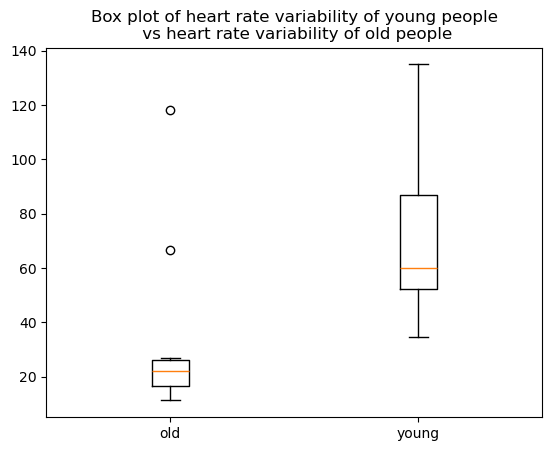

In [102]:
plt.boxplot([ hrv_df_old['RMSSD'], 
             hrv_df_young['RMSSD']],
             labels = ['old','young']
           );
plt.title('Box plot of heart rate variability of young people\n vs heart rate variability of old people')


Task 6.

6a -Write a short discussion that discusses the key observations that can be made from the Poincare plots, in terms of how they relate to the statistical analysis performed.

It can be seen on the poincare plots that most of the plots for the old people showed less variation with points accummulating over a small region of the graph. This indicates that there are relatively small differences in the values of the majority of the NN beat intervals . Whereas the plots for the young people showed a wider spread along an imaginary diagonal(roughly at an angle of 45 degrees) line. This indicates the presence of phases of several shorter and longer intervals in the recording compared to the data for old people. This is an evidence of higher variability. Furthermore, for the young people, the scatter plots covered wider areas around the imaginary diagonal line when compared to most of the plots for the older people, covering larger regions of each plot.This indicates a presence of more varied beat to beat intervals(NN(i) to  NN(i+1) intervals). Again, an evidence of higher variability in younger people.





6b -In this investigation we have applied the t-test to detect statistical differences. Critically evaluate the applicability of the test and suggest what additional or alternative approaches would be suitable (you may demonstrate if your wish).

The T-test is parameteric test designed for carrying out statical analysis on data that are normally distributed. Therefore, before carrying out a t-test, an appropriate thing to do is to check for normality in the distributions of the dataset. This could be done by using a q-q plot which compare the quantiles of the distribution of the datasets to the quantiles of a normal distribution. Also, we can use shapiro test to test for normality.While the central limit theorem allows us to use the t-test to carry out statistical analysis on datasets that are not normally distributed when n is large, in a case where any of the datasets we are using for comparison do not have a normal distribution and the size of the data (n) is less than 30, we can use a non-parametric test to determine statistical difference between two datasets. for example the Mann–Whitney U test will be appropriate for independent datasets like the ones that were used in the above tests if statistical evidence prove they are not normally distributed since the size of each dataset(10) is less than 30. 



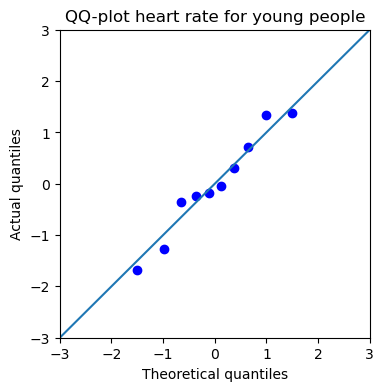

In [104]:
# construct a QQ plot for the heart rate in young people data
m = hrv_df_young['mean_bpm'].mean()
s = hrv_df_young['mean_bpm'].std()

fig, ax = plt.subplots(figsize=(4,4))
result_young = stats.probplot( (hrv_df_young['mean_bpm']-m)/s , plot=ax, fit=False)

ax.set_title("QQ-plot heart rate for young people")
ax.set_ylabel("Actual quantiles")
ax.set_xlabel("Theoretical quantiles")
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.plot([-3,3],[-3,3],'-')

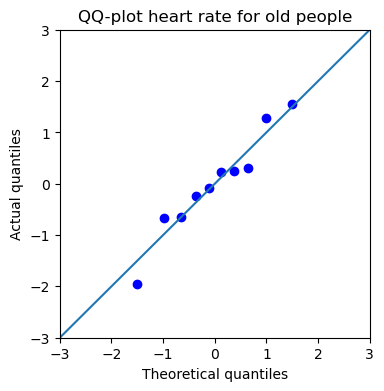

In [106]:
# construct a QQ plot for the heart rate  in old people data
m = hrv_df_old['mean_bpm'].mean()
s = hrv_df_old['mean_bpm'].std()

fig, ax = plt.subplots(figsize=(4,4))
result_old = stats.probplot( (hrv_df_old['mean_bpm']-m)/s , plot=ax, fit=False)

ax.set_title("QQ-plot heart rate for old people")
ax.set_ylabel("Actual quantiles")
ax.set_xlabel("Theoretical quantiles")
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.plot([-3,3],[-3,3],'-')

In [108]:
#carry out test for normality for heart rate 
#for young people data
result = stats.shapiro(hrv_df_young['mean_bpm'])
result

ShapiroResult(statistic=0.9488357237264639, pvalue=0.6547449484943735)

In [110]:
#for old people data
result = stats.shapiro(hrv_df_old['mean_bpm'])
result

ShapiroResult(statistic=0.9531123865773711, pvalue=0.7053807245572215)

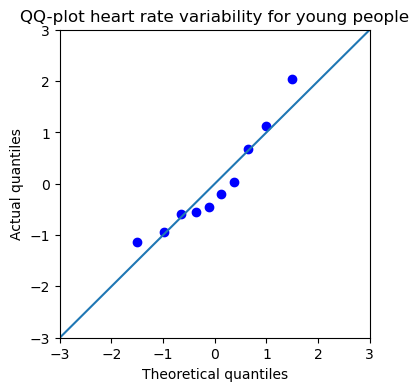

In [112]:
# construct a QQ plot for the heart rate variability in young people data
m = hrv_df_young['RMSSD'].mean()
s = hrv_df_young['RMSSD'].std()

fig, ax = plt.subplots(figsize=(4,4))
result_young = stats.probplot( (hrv_df_young['RMSSD']-m)/s , plot=ax, fit=False)

ax.set_title("QQ-plot heart rate variability for young people")
ax.set_ylabel("Actual quantiles")
ax.set_xlabel("Theoretical quantiles")
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.plot([-3,3],[-3,3],'-')

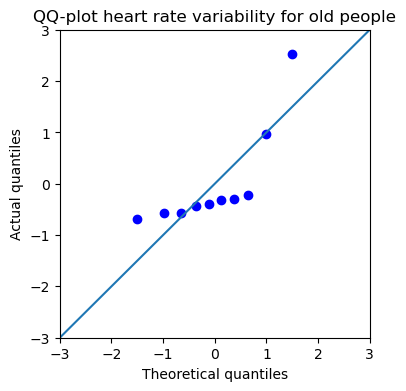

In [114]:
# construct a QQ plot for the heart rate variability in old people data
m = hrv_df_old['RMSSD'].mean()
s = hrv_df_old['RMSSD'].std()

fig, ax = plt.subplots(figsize=(4,4))
result_old = stats.probplot( (hrv_df_old['RMSSD']-m)/s , plot=ax, fit=False)

ax.set_title("QQ-plot heart rate variability for old people")
ax.set_ylabel("Actual quantiles")
ax.set_xlabel("Theoretical quantiles")
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.plot([-3,3],[-3,3],'-')

In [116]:
#carry out test for normality for heart rate variability
#for young people data
result = stats.shapiro(hrv_df_young['RMSSD'])
result

ShapiroResult(statistic=0.9091016592039204, pvalue=0.27487721674929416)

In [118]:
#for old people data
result = stats.shapiro(hrv_df_old['RMSSD'])
result

ShapiroResult(statistic=0.6633691729388931, pvalue=0.0003178964079961441)

For heart rate, the qqplots showed that the distribution of the heart rate in both old and young is close to a normal distribution. This was further confirmed in the shapiro tests as the p-value for both data were higher than the significant level of 0.05. In the shapiro test, the null hypothesis states that the distribution is normal. Therefore, we can assume that distribution of the data for the two samples are normally distributed. A t-test is appropriate in this scenario. However, for heart rate variability, the qqplots and the shapiro test showed that heart rate variability for young people is similar to a normal distribution while heart rate variability for old people is not normally disributed. In this scenario, a non-parametric Mann-Whitney U test is an appropriate test for the analysis.

6c - What additional plots may be useful to view each recording before including it in the analysis. You may include an example plot/plots and explain why this would be useful.

It may be useful to plot a bar chart or a pie chart showing the frequency/percentage of different types of heart beats present in each recording. This is because a recording with very high amount of  non-normal sinus rythm heart beats could mean the individual whose heartbeats was recorded might be suffering from a heart disease or condition. Excluding such individual's record would allow the test to assess the effects of only age group on heart rate and heart rate variability.

In [120]:
df = pd.read_csv("investigating_hrv_dataset/y01.csv")
data =df['type'].value_counts(dropna=False, ascending=True).to_dict()
data

{'V': 1, '+': 1, 'N': 8708}

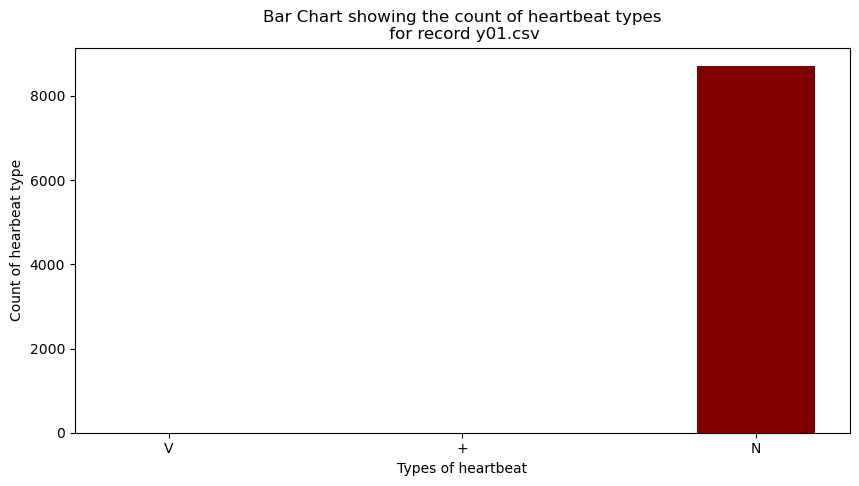

In [122]:
#plotting a bar chart for the record y01.csv
heartbeat_type = list(data.keys())
heartbeat_count = list(data.values())
 
fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(heartbeat_type, heartbeat_count, color ='maroon', 
        width = 0.4)

plt.xlabel("Types of heartbeat")
plt.ylabel("Count of hearbeat type")
plt.title("Bar Chart showing the count of heartbeat types\n for record y01.csv")
plt.show()

As can be seen in the above plots and from the results of the previous code, the number of non-normal rythm heartbeats is extremely small. There are 2 non-normal rythm heartbeats out of 8710 heartbeats. Therefore, this recording should be included for our analysis.

6d- Explore the current research in this area and briefly set out the current understanding of heart rate and heart rate variability by age and gender.

Generally, from the exploration of current research, it is currently understood that heart rate variability significantly reduces with age. This is the same for heart rate but in a much slower rate of redution. However, there is little consensus regarding the effect of gender on heart rate and heart rate variability. Umetani et al. (1998) in their experiment showed that heart rate variability and heart rate declined from decade to decade in both male and females. In their experiment, they showed that heart rate variability was higher in male than in females for age group 0 t0 30years. The heart rate variability difference between the two genders largely reduced between 30 and 50 and did not exist in groups with age greater than 50 years. They also found that heart rate was higher for females than for males from age 0-50. Heart rate was more or less the same for the two genders after 50 years. Several years ag,o heart beat intervals with regular frequencies like a monotrome were thought by reseachers to be produced from a healthy heart, but it is now understood by scientists that heartbeats of a heathy heart should be irregular(Shaffer et al., 2014). Furthermore, heart rate variability is also an indicator of resilience in psychological and flexible behaviour, showing an individual's ability to effectively respond to constantly changing environmental or social demands(Shaffer et al., 2014). These are traits or characteristics that are relatively often more present in younger people. Geovanin et. al(2020) also showed in their research that HRV declines with age. They also showed that HRV declines by gender. In their experiment, they showed that, overall, heart rate variability decreased across males and females from decade to decade. They also showed that in all age groups(decades), there was a consistently higher variability in heart rate for males compared to female. (Natarajan et al., 2020) again showed that heart variability decreases with age. Their experiment was inconclusive about the effect of gender on heart rate variability.

REFERENCES

Heart rate variability with photoplethysmography in 8 million individuals: a cross-sectional study - Aravind Natarajan, Alexandros Pantelopoulos, Hulya Emir-Farinas, Pradeep Natarajan.



Twenty-Four Hour Time Domain Heart Rate Variability and Heart Rate: Relations to Age and Gender Over Nine Decades - Ken Umetani, Donald H. Singer, Rollin Mccraty,  Mike Atkinso.

n
A healthy heart is not a metronome: an integrative review of the heart's anatomy and heart rate variability – Fred Sahaffer, Christopher L. Zerr, Rollin Mccra.

ty
Age and sex differences in heart variability and vagal specific patterns - Glaucylara Reis Geovanini, Enio Rodrigues Vasques, Rafael de Oliveira Alvim, José Geraldo Mill, Rodrigo Varejão Andreão, Bruna Kim Vasques, Alexandre Costa Pereira and Jose Eduardo Krie.ger
